# Regresión Lineal Simple - Leads GAC por Canal
Siguiendo la misma estructura y estilo del ejercicio de referencia (`car_crashes`), pero filtrando por grupo (Canal) para modelar la tendencia de Leads a lo largo del tiempo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cargamos el archivo csv con pandas (se salta el encabezado con el título/meta del reporte)
df = pd.read_csv("Analisis_GAC_Full7agosto_2026_Leads_por_Canal_.csv", skiprows=3)
df.head(10)

,Canal,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,...,Obj Jun,Obj Historicos,Proyección,%,Aporte promedio,%.1,Ajuste,Unnamed: 38,Unnamed: 39,Unnamed: 40
0,Piso,0.0,329.0,19.0,76.0,87.0,55.0,92.0,77.0,57.0,...,95.0,117.0,76.0,100%,69.0,6%,9.1%,NaN,NaN,NaN
1,Plazas,0.0,0.0,0.0,25.0,28.0,68.0,294.0,248.0,52.0,...,350.0,462.0,280.0,100%,273.0,22%,36.1%,NaN,NaN,NaN
2,Eventos,0.0,7.0,0.0,5.0,0.0,71.0,4.0,5.0,1.0,...,55.0,32.0,44.0,9%,19.0,2%,2.5%,NaN,NaN,NaN
3,Planta,0.0,6.0,52.0,127.0,60.0,376.0,237.0,135.0,1030.0,...,200.0,0.0,160.0,100%,465.0,38%,0.0%,NaN,NaN,NaN
4,Digitales,0.0,6.0,5.0,18.0,69.0,87.0,113.0,57.0,107.0,...,500.0,395.0,400.0,85%,234.0,19%,30.9%,NaN,NaN,NaN
5,Otros,0.0,195.0,102.0,165.0,178.0,310.0,214.0,887.0,68.0,...,80.0,274.0,64.0,100%,162.0,13%,21.4%,NaN,NaN,NaN
6,Total,0.0,543.0,178.0,416.0,422.0,967.0,954.0,1409.0,1315.0,...,1280.0,1280.0,1024.0,100%,1222.0,100%,100%,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Leads GAC,0.0,342.0,24.0,124.0,184.0,281.0,503.0,387.0,217.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#Limpieza: nos quedamos solo con la columna Canal y las 30 columnas de meses (2.5 años),
#dejando fuera columnas de metas/proyecciones y filas que no son canales (Total, Leads GAC, vacías)
month_cols = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto',
              'Septiembre', 'Octubre', 'Noviembre', 'Diciembre',
              'Enero.1', 'Febrero.1', 'Marzo.1', 'Abril.1', 'Mayo.1', 'Junio.1', 'Julio.1',
              'Agosto.1', 'Septiembre.1', 'Octubre.1', 'Noviembre ', 'Diciembre ',
              'Enero.2', 'Febrero.2', 'Marzo.2', 'Abril.2', 'Mayo ', 'Junio ']

canales = ['Piso', 'Plazas', 'Eventos', 'Planta', 'Digitales', 'Otros']

df['Canal'] = df['Canal'].str.strip()
df_canales = df[df['Canal'].isin(canales)][['Canal'] + month_cols].copy()
df_canales

,Canal,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,...,Septiembre.1,Octubre.1,Noviembre,Diciembre,Enero.2,Febrero.2,Marzo.2,Abril.2,Mayo,Junio
0,Piso,0.0,329.0,19.0,76.0,87.0,55.0,92.0,77.0,57.0,...,58.0,72.0,81.0,76.0,105.0,94.0,105.0,79.0,113.0,85.0
1,Plazas,0.0,0.0,0.0,25.0,28.0,68.0,294.0,248.0,52.0,...,312.0,324.0,274.0,325.0,290.0,433.0,401.0,351.0,352.0,403.0
2,Eventos,0.0,7.0,0.0,5.0,0.0,71.0,4.0,5.0,1.0,...,1.0,14.0,46.0,42.0,89.0,4.0,89.0,1.0,0.0,1.0
3,Planta,0.0,6.0,52.0,127.0,60.0,376.0,237.0,135.0,1030.0,...,364.0,401.0,204.0,452.0,484.0,297.0,673.0,391.0,233.0,449.0
4,Digitales,0.0,6.0,5.0,18.0,69.0,87.0,113.0,57.0,107.0,...,312.0,287.0,350.0,405.0,438.0,338.0,307.0,443.0,427.0,299.0
5,Otros,0.0,195.0,102.0,165.0,178.0,310.0,214.0,887.0,68.0,...,53.0,94.0,106.0,234.0,93.0,107.0,103.0,128.0,114.0,78.0


In [4]:
#Transformamos de formato ancho (canal x mes) a formato largo (Canal, Mes, Leads)
#para poder filtrar por grupo y usar 'Mes' como variable numérica en la regresión
df_largo = df_canales.melt(id_vars='Canal', var_name='Mes_Label', value_name='Leads')

#Creamos un índice de mes numérico (1 a 30) respetando el orden cronológico original
df_largo['Mes'] = df_largo.groupby('Canal').cumcount() + 1
df_largo

,Canal,Mes_Label,Leads,Mes
0,Piso,Enero,0.0,1
1,Plazas,Enero,0.0,1
2,Eventos,Enero,0.0,1
3,Planta,Enero,0.0,1
4,Digitales,Enero,0.0,1
...,...,...,...,...
175,Plazas,Junio,403.0,30
176,Eventos,Junio,1.0,30
177,Planta,Junio,449.0,30
178,Digitales,Junio,299.0,30


<Axes: xlabel='Mes', ylabel='Leads'>

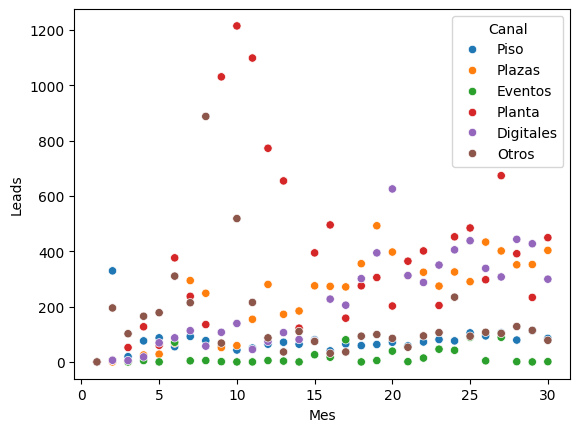

In [5]:
#Imprimimos el scatter plot entre la variable dependiente (Leads) e independiente (Mes)
#para observar el comportamiento en su dispersión, separado por canal
sns.scatterplot(x='Mes', y='Leads', hue='Canal', data=df_largo)

## Filtramos por grupo (Canal)
A continuación se muestra el flujo completo para **un canal** (Piso) como ejemplo, y después se repite el mismo procedimiento para los demás canales.

In [6]:
#Filtramos el DataFrame por el canal que queremos modelar
canal_actual = 'Piso'
df_canal = df_largo[df_largo['Canal'] == canal_actual]
df_canal.head()

,Canal,Mes_Label,Leads,Mes
0,Piso,Enero,0.0,1
6,Piso,Febrero,329.0,2
12,Piso,Marzo,19.0,3
18,Piso,Abril,76.0,4
24,Piso,Mayo,87.0,5


In [7]:
#Declaramos las variables dependiente e independiente para la regresión lineal
Vars_Indep = df_canal[['Mes']]
Var_Dep = df_canal['Leads']

In [8]:
#%pip install scikit-learn

In [9]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [10]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Mes'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.02892102]),
 'rank_': 1,
 'singular_': array([47.40780526]),
 'intercept_': np.float64(77.21839080459772)}

In [12]:
#Construimos el modelo matemático a partir de los coeficientes
pendiente = model.coef_[0]
intercepto = model.intercept_
print(f'Modelo matemático: y = {pendiente:.4f}(Mes) + {intercepto:.4f}')

Modelo matemático: y = 0.0289(Mes) + 77.2184


In [13]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep, Var_Dep)

2.293788254881246e-05

In [14]:
#Predecimos los valores de Leads a partir de la variable "Mes"
y_pred = model.predict(X=Vars_Indep)
y_pred

array([77.24731183, 77.27623285, 77.30515387, 77.3340749 , 77.36299592,
       77.39191694, 77.42083797, 77.44975899, 77.47868001, 77.50760104,
       77.53652206, 77.56544308, 77.59436411, 77.62328513, 77.65220615,
       77.68112718, 77.7100482 , 77.73896923, 77.76789025, 77.79681127,
       77.8257323 , 77.85465332, 77.88357434, 77.91249537, 77.94141639,
       77.97033741, 77.99925844, 78.02817946, 78.05710048, 78.08602151])

In [15]:
#Insertamos la columna de predicciones en el DataFrame
df_canal = df_canal.copy()
df_canal.insert(0, 'Predicciones', y_pred)
df_canal

,Predicciones,Canal,Mes_Label,Leads,Mes
0,77.247312,Piso,Enero,0.0,1
6,77.276233,Piso,Febrero,329.0,2
12,77.305154,Piso,Marzo,19.0,3
18,77.334075,Piso,Abril,76.0,4
24,77.362996,Piso,Mayo,87.0,5
30,77.391917,Piso,Junio,55.0,6
36,77.420838,Piso,Julio,92.0,7
42,77.449759,Piso,Agosto,77.0,8
48,77.478680,Piso,Septiembre,57.0,9
54,77.507601,Piso,Octubre,43.0,10


<Axes: xlabel='Mes', ylabel='Leads'>

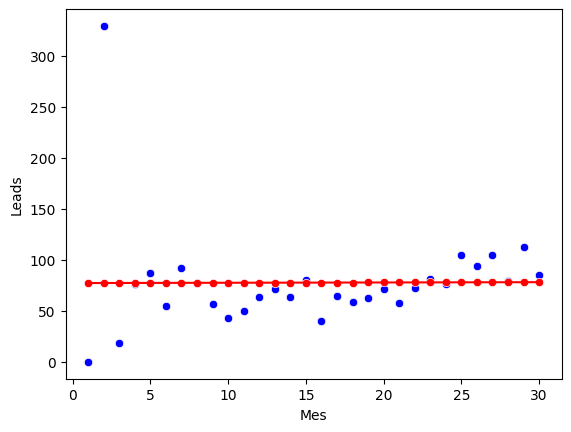

In [16]:
#Visualizamos la gráfica comparativa entre el Leads real y el Leads predecido
sns.scatterplot(x='Mes', y='Leads', color="blue", data=df_canal)
sns.scatterplot(x='Mes', y='Predicciones', color="red", data=df_canal)
sns.lineplot(x='Mes', y='Predicciones', color="red", data=df_canal)

In [17]:
#Corroboramos cuál es el coeficiente de Determinación de nuestro modelo
coef_Deter = model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

2.293788254881246e-05

In [18]:
#Corroboramos cuál es el coeficiente de Correlación de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
coef_Correl

np.float64(0.004789350952771415)

## Repetimos el modelo para todos los canales
Ahora aplicamos el mismo procedimiento (filtrar por grupo → regresión simple Leads ~ Mes) a cada uno de los canales, para comparar tendencias entre ellos.

In [19]:
#Repetimos el mismo flujo de regresión simple para cada canal y guardamos los resultados
resultados = []

for canal_actual in canales:
    df_canal = df_largo[df_largo['Canal'] == canal_actual]
    Vars_Indep = df_canal[['Mes']]
    Var_Dep = df_canal['Leads']

    model = LinearRegression()
    model.fit(X=Vars_Indep, y=Var_Dep)

    coef_Deter = model.score(X=Vars_Indep, y=Var_Dep)
    coef_Correl = np.sqrt(coef_Deter)

    resultados.append({
        'Canal': canal_actual,
        'Pendiente': model.coef_[0],
        'Intercepto': model.intercept_,
        'R2': coef_Deter,
        'Correlación': coef_Correl
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,Canal,Pendiente,Intercepto,R2,Correlación
0,Piso,0.028921,77.218391,0.000023,0.004789
1,Plazas,14.108565,17.717241,0.717646,0.847140
2,Eventos,0.941268,3.910345,0.083766,0.289424
3,Planta,4.751057,315.025287,0.017842,0.133575
4,Digitales,16.131924,-38.678161,0.717767,0.847211
5,Otros,-5.235373,234.914943,0.072985,0.270158


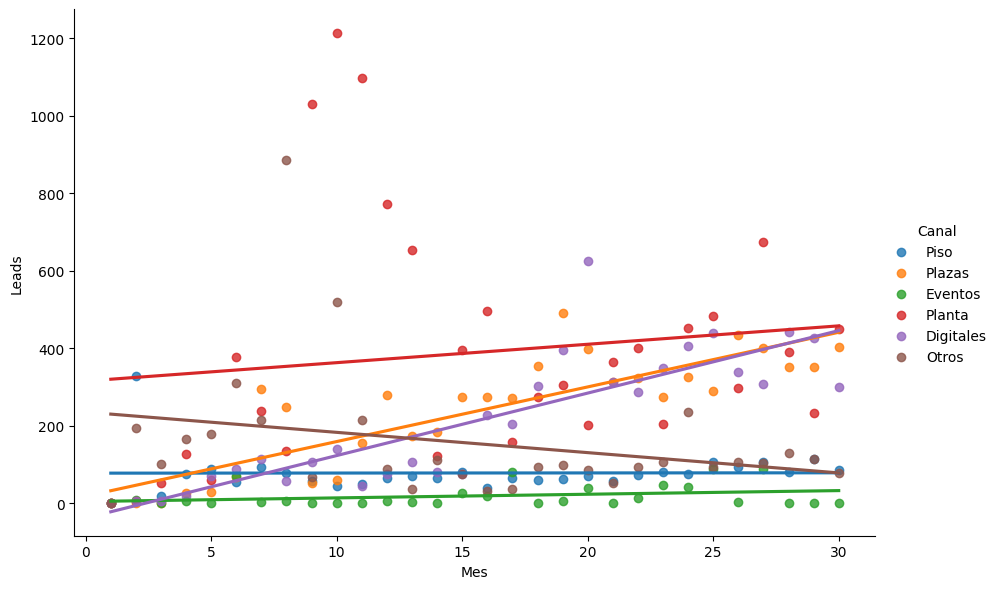

In [20]:
#Graficamos la comparación de tendencias (Leads reales) entre todos los canales
sns.lmplot(x='Mes', y='Leads', hue='Canal', data=df_largo, height=6, aspect=1.5, ci=None)

## Correlación entre canales (mapa de calor)
Para que el heatmap tenga sentido necesitamos varias columnas numéricas en paralelo — aquí usamos los canales como columnas y los meses como filas, para ver qué canales se mueven juntos a lo largo del tiempo.

In [21]:
#Convertimos el DataFrame largo a formato ancho: filas=Mes, columnas=Canal, valores=Leads
df_ancho_canales = df_largo.pivot(index='Mes', columns='Canal', values='Leads')
df_ancho_canales

Canal,Digitales,Eventos,Otros,Piso,Planta,Plazas
Mes,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0
2,6.0,7.0,195.0,329.0,6.0,0.0
3,5.0,0.0,102.0,19.0,52.0,0.0
4,18.0,5.0,165.0,76.0,127.0,25.0
5,69.0,0.0,178.0,87.0,60.0,28.0
6,87.0,71.0,310.0,55.0,376.0,68.0
7,113.0,4.0,214.0,92.0,237.0,294.0
8,57.0,5.0,887.0,77.0,135.0,248.0
9,107.0,1.0,68.0,57.0,1030.0,52.0


In [22]:
#Encontramos todas las correlaciones entre canales
Corr_Canales = df_ancho_canales.corr()
Corr_Canales

Canal,Digitales,Eventos,Otros,Piso,Planta,Plazas
Canal,,,,,,
Digitales,1.000000,0.322977,-0.235735,0.001117,-0.008522,0.784427
Eventos,0.322977,1.000000,-0.084340,0.069871,0.000719,0.202378
Otros,-0.235735,-0.084340,1.000000,0.063408,0.088146,-0.168488
Piso,0.001117,0.069871,0.063408,1.000000,-0.224559,-0.033115
Planta,-0.008522,0.000719,0.088146,-0.224559,1.000000,0.016554
Plazas,0.784427,0.202378,-0.168488,-0.033115,0.016554,1.000000


In [23]:
#Encontramos el valor absoluto de todas las correlaciones entre canales
Corr_Canales1 = abs(Corr_Canales)
Corr_Canales1

Canal,Digitales,Eventos,Otros,Piso,Planta,Plazas
Canal,,,,,,
Digitales,1.000000,0.322977,0.235735,0.001117,0.008522,0.784427
Eventos,0.322977,1.000000,0.084340,0.069871,0.000719,0.202378
Otros,0.235735,0.084340,1.000000,0.063408,0.088146,0.168488
Piso,0.001117,0.069871,0.063408,1.000000,0.224559,0.033115
Planta,0.008522,0.000719,0.088146,0.224559,1.000000,0.016554
Plazas,0.784427,0.202378,0.168488,0.033115,0.016554,1.000000


<Axes: xlabel='Canal', ylabel='Canal'>

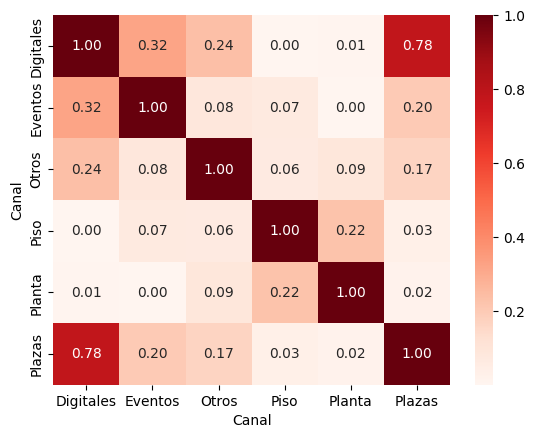

In [24]:
#Graficamos el mapa de calor de los coeficientes de correlación entre canales
Heat_Map = sns.heatmap(Corr_Canales1, cmap='Reds', annot=True, fmt=".2f")
Heat_Map